# Corr_2PCF: Isotropic and Anisotropic Two-Point Statistics

This notebook continues from `quick_start.ipynb` and uses its saved base `SFCField` for the isotropic and lightweight anisotropic calculations. It follows the same high-level-to-low-level progression as the other PyHermes examples:

1. run isotropic and anisotropic `Corr_2PCF` tasks from YAML configurations;
2. inspect saved `Corr2PCFData` products and make standard plots;
3. override a high-level task from Python;
4. reconstruct $\xi(s)$ directly from field convolution and spatial averaging;
5. construct custom isotropic and anisotropic binning windows with the low-level `WindowFunc` API;
6. load the saved production-resolution RSD results used in the paper.

The older exploratory cosine and disk/cylinder/cylshell scans are intentionally omitted so that the notebook remains a focused user guide and a companion to Section 4.3.1 of the paper.

In [1]:

from pathlib import Path
import copy
import os

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np
from numba import njit

from pyhermes.base.sfc_projection import SFCProjection
from pyhermes.io import Corr2PCFData, SFCField, WindowFunc
from pyhermes.utils.plot import plot_corr2pcf_2d
from pyhermes.param.parambase import read_param
from pyhermes.theory.corr2pcf import Corr_2PCF
from pyhermes.utils.special_functions import jn_numba

cwd = Path.cwd().resolve()
if cwd.name == "notebooks" and cwd.parent.name == "examples":
    PROJECT_ROOT = cwd.parent.parent
elif cwd.name == "examples":
    PROJECT_ROOT = cwd.parent
elif (cwd / "examples").exists():
    PROJECT_ROOT = cwd
else:
    raise RuntimeError("Run this notebook from the project root or examples/notebooks.")

EXAMPLES_DIR = PROJECT_ROOT / "examples"
OUTPUT_DIR = EXAMPLES_DIR / "output"
FIGS_DIR = EXAMPLES_DIR / "figs"
FIGS_DIR.mkdir(exist_ok=True)

os.chdir(EXAMPLES_DIR)

THREADS = 8
SFC_PATH = OUTPUT_DIR / "quijote8000_snap004_sfc.pkl"

STYLE = {
    "font.family": "serif",
    "font.size": 16,
    "axes.labelsize": 17,
    "axes.titlesize": 17,
    "legend.fontsize": 12,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.grid": False,
}
COLORS = {"blue": "#1f77b4", "orange": "#ff7f0e", "green": "#2ca02c"}
plt.rcParams.update(STYLE)

print(f"project root: {PROJECT_ROOT}")
print(f"output dir  : {OUTPUT_DIR}")


project root: /Users/xutengpeng/xutp/PycharmProjects/PyHermes
output dir  : /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples/output


## 1. From configuration to result

A two-point workflow has three main objects. `Corr_2PCF` describes and executes the estimator, `Corr2PCFData` reads its saved products, and `WindowFunc` provides the lower-level Fourier-space windows used by the estimator. Most users can begin with the first two objects and only use `WindowFunc` when defining a new binning geometry.

### 1.1 High-level YAML tasks

The isotropic example uses `configs/param_2pcf.yaml`, while the lightweight anisotropic example uses `configs/param_2pcf_smu_test.yaml`. The latter deliberately contains only a $6\times6$ sampling grid so that it can be run interactively.

In [2]:
ISO_CONFIG = Path("./configs/param_2pcf.yaml")
SMU_TEST_CONFIG = Path("./configs/param_2pcf_smu_test.yaml")

iso_params = read_param(config_path=str(ISO_CONFIG))
smu_test_params = read_param(config_path=str(SMU_TEST_CONFIG))

print("Isotropic task:", iso_params["Corr_2PCF"])
print("Lightweight anisotropic task:", smu_test_params["Corr_2PCF"])


23:42:50 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: 'configs/param_2pcf.yaml'
23:42:50 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
23:42:50 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: 'configs/param_2pcf_smu_test.yaml'
23:42:50 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
Isotropic task: {'sfc_field': './output/quijote8000_snap004_sfc.pkl', 'random': 'uniform', 'binning_window': 'shell', 'sampling': {'s': {'min': 0.0, 'max': 150.0, 'n': 31}}, 'products': ['dd', 'dr', 'rd', 'xi'], 'threads': 2, 'fout_path': './output/quijote8000_snap004_2pcf.pkl'}
Lightweight anisotropic task: {'sfc_field': './output/quijote8000_snap004_sfc.pkl', 'random': 'uniform', 'binning_window': 'ring', 'sampling': {'s': {'min': 0.0, 'max': 150.0, 'n': 6}, 'mu': {'min': 0.0, 'max': 1.0, 'n': 6}}, 'threads': 4, 'products': 'xi', 'fout_path': './output/quijote8000_snap004_2pcf_smu_test.pkl'

The repository runner reads the same YAML file on every MPI rank. These two commands generate the saved isotropic result and the lightweight $(s,\mu)$ result used below. On a machine without MPI, the same tasks can be executed through the Python interface in Section 1.3.

In [3]:
! mpirun -np 2 python ./scripts/run_2pcf.py ./configs/param_2pcf.yaml

23:42:52 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_2pcf.yaml'
23:42:52 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
23:42:52 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
23:42:52 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.sfc_field' from 'empty' to './output/quijote8000_snap004_sfc.pkl'
23:42:52 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.random' from 'None' to 'uniform'
23:42:52 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.binning_window'.
23:42:52 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.sampling'.
23:42:52 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.products' from 'xi' to '['dd', 'dr', 'rd', 'xi']'
23:42:52 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.threads' fro

In [4]:
! mpirun -np 2 python ./scripts/run_2pcf.py ./configs/param_2pcf_smu_test.yaml

23:43:05 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_2pcf_smu_test.yaml'
23:43:05 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
23:43:05 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
23:43:05 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.sfc_field' from 'empty' to './output/quijote8000_snap004_sfc.pkl'
23:43:05 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.random' from 'None' to 'uniform'
23:43:05 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.binning_window'.
23:43:05 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.sampling'.
23:43:05 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.threads' from '1' to '4'
23:43:05 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.fout_path' from 'empty' to '

### 1.2 Saved result objects

`Corr2PCFData` exposes the requested count products and derived correlation function as arrays. The isotropic configuration requests `dd`, `dr`, `rd`, and `xi`; `rr` is also available because it is required by the estimator. The first plot verifies the stored $\xi$ against the explicit Landy--Szalay combination.

23:43:18 - INFO - pyhermes.io.base:Corr2PCFData - Reading 2PCF data from ---> ./output/quijote8000_snap004_2pcf.pkl <---
23:43:18 - INFO - pyhermes.io.base:Corr2PCFData - s: Num = 31, Min = 0, Max = 150
23:43:18 - INFO - pyhermes.io.base:Corr2PCFData - Products loaded: ['dd', 'dr', 'rd', 'delta_dd', 'rr', 'xi']


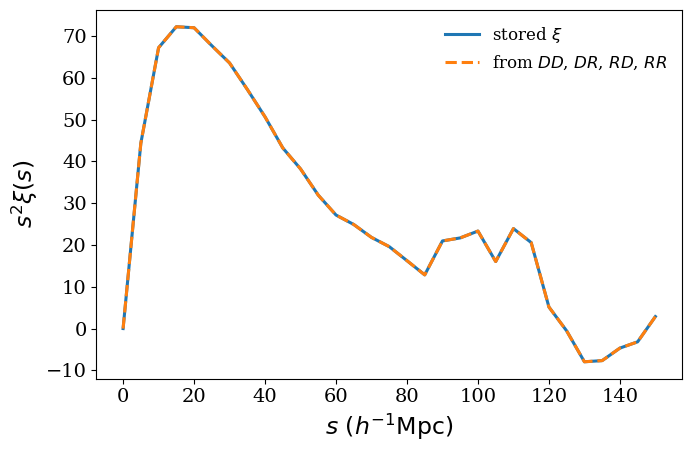

In [5]:
corr_s = Corr2PCFData(data_path="./output/quijote8000_snap004_2pcf.pkl", threads=THREADS)

fig, ax = plt.subplots(figsize=(7.2, 4.8))
ax.plot(corr_s.s, corr_s.s**2 * corr_s.xi, color=COLORS["blue"], lw=2.2, label=r"stored $\xi$")

if all(getattr(corr_s, name, None) is not None for name in ("dd", "dr", "rd", "rr")):
    xi_landy_szalay = (corr_s.dd - corr_s.dr - corr_s.rd + corr_s.rr) / corr_s.rr
    ax.plot(corr_s.s, corr_s.s**2 * xi_landy_szalay, "--", color=COLORS["orange"], lw=2.2, label=r"from $DD$, $DR$, $RD$, $RR$")

ax.set_xlabel(r"$s\ (h^{-1}\mathrm{Mpc})$")
ax.set_ylabel(r"$s^2\xi(s)$")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


23:43:18 - INFO - pyhermes.io.base:Corr2PCFData - Reading 2PCF data from ---> ./output/quijote8000_snap004_2pcf_smu_test.pkl <---
23:43:18 - INFO - pyhermes.io.base:Corr2PCFData - s: Num = 6, Min = 0, Max = 150
23:43:18 - INFO - pyhermes.io.base:Corr2PCFData - mu: Num = 6, Min = 0, Max = 1
23:43:18 - INFO - pyhermes.io.base:Corr2PCFData - Products loaded: ['delta_dd', 'rr', 'xi']


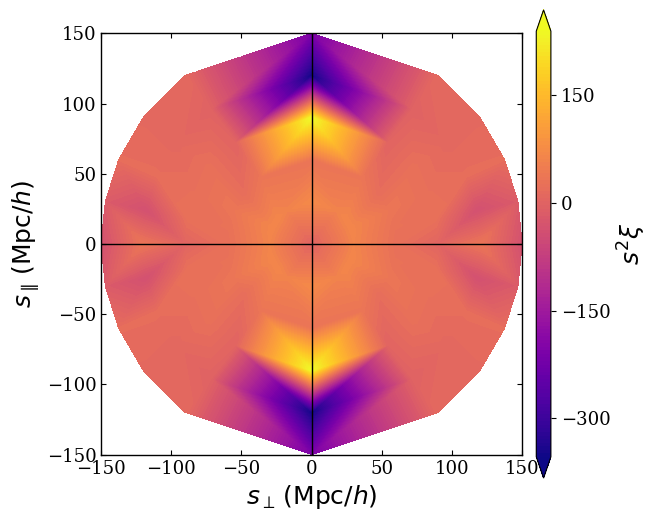

In [6]:
corr_smu_test = Corr2PCFData(
    data_path="./output/quijote8000_snap004_2pcf_smu_test.pkl",
    threads=THREADS,
)
plot_corr2pcf_2d(corr_smu_test, s_min=0.0)
plt.tight_layout()
plt.show()


### 1.3 Run and override a task in Python

The YAML dictionary can also initialize `Corr_2PCF` directly. Attributes assigned afterwards override the corresponding configuration entries. Here the sampling grid is shortened for an interactive run, and `save_result=False` returns the result without replacing the production output file.

In [7]:
interactive_params = copy.deepcopy(iso_params)
interactive_task = Corr_2PCF(param_task=interactive_params)
interactive_task.sampling["s"] = np.linspace(5.0, 150.0, 16)
interactive_task.products = "xi"
interactive_task.threads = THREADS
corr_s_interactive = interactive_task.run(save_result=False)


23:43:18 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
23:43:18 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.sfc_field' from 'empty' to './output/quijote8000_snap004_sfc.pkl'
23:43:18 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.random' from 'None' to 'uniform'
23:43:18 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.binning_window'.
23:43:18 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.sampling'.
23:43:18 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.products' from 'xi' to '['dd', 'dr', 'rd', 'xi']'
23:43:18 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.threads' from '1' to '2'
23:43:18 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.fout_path' from 'empty' to './output/quijote8000_snap004_2pcf.pkl'
23:43:18 - INFO - pyhermes.pipeline.pipeline

## 2. Direct low-level reconstruction of $\xi(s)$

The high-level `Corr_2PCF` task evaluates the same field--window--field operation at every requested separation. This section exposes that operation directly, following the low-level reconstruction style used in `corr3pcf.ipynb`.

For a uniform random field, let

$$
\rho = \langle D\rangle, \qquad \Delta D = D-\rho, \qquad RR=\rho^2.
$$

After the optional spherical smoothing $\Delta D_w=\Delta D@W_{\rm sphere}$, the shell-binned estimator at one separation is

$$
\xi_w(s)=\frac{\left\langle\left(\Delta D_w@W_{\rm shell}(s)\right)\Delta D_w\right\rangle}{RR}.
$$

Here `@` performs the Fourier-space convolution, multiplication forms the local field product, and `as_array().mean()` takes its spatial average. Consequently, the helper below can evaluate one chosen $s$ without constructing a complete `Corr_2PCF` task.

In [8]:
# Build the multiresolution coefficient field directly from the catalogue.
projection_params = read_param(config_path="./configs/param_sfc_projection.yaml")
projection_params["SFCProjection"]["threads"] = THREADS
D = SFCProjection(projection_params).run(save_result=False)
D.threads = THREADS

# For the uniform-random shortcut, the random field is the mean density rho.
rho = D.field_mean_density(value_unit="grid")
RR = rho ** 2
deltaD = D - rho

# Smooth the fluctuation field with a spherical top-hat of radius 5 h^-1 Mpc.
W_smooth = WindowFunc(
    {"type": "sphere", "len_args": {"R": 5.0}},
    D.sfc_info,
    threads=THREADS,
)
deltaD_w = deltaD @ W_smooth

23:43:23 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_sfc_projection.yaml'
23:43:23 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
23:43:23 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <base> ...
23:43:23 - INFO - pyhermes.param.parambase:ParamBase - Default 'SFCProjection.fin.path' from 'empty' to 'https://pyhermes.astroslacker.com/downloads/quijote_halos_8000_snap004.npz'
23:43:23 - INFO - pyhermes.param.parambase:ParamBase - Default 'SFCProjection.fin.format' from 'bin' to 'npz'
23:43:23 - INFO - pyhermes.param.parambase:ParamBase - Default 'SFCProjection.fin.download.cache_path' from 'empty' to './data/quijote_halos_8000_snap004.npz'
23:43:23 - INFO - pyhermes.param.parambase:ParamBase - Default 'SFCProjection.fin.download.sha256' from 'empty' to 'b2b4b8c2fb91fa857e21b43d943cc32a2c423ee7cf5d7f13dede608264b08ef6'
23:43:23 - INFO - pyhermes.param.parambase:ParamBase - Defaul

In [9]:
def xi_at_s(delta_field, s, RR, threads=THREADS):
    """Evaluate the shell-binned 2PCF at one separation s."""
    W_shell = WindowFunc(
        {"type": "shell", "len_args": {"R": float(s)}},
        delta_field.sfc_info,
        threads=threads,
    )
    local_pair_product = (delta_field @ W_shell) * delta_field
    return float(local_pair_product.as_array().mean() / RR)

s_demo = 40.0
xi_demo = xi_at_s(deltaD_w, s_demo, RR)
print(f"xi({s_demo:.1f} h^-1 Mpc) = {xi_demo:.6e}")

xi(40.0 h^-1 Mpc) = 3.198802e-02


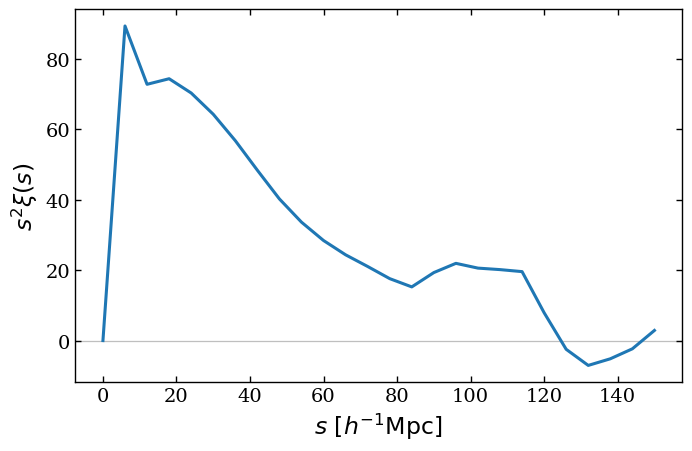

In [10]:
s_direct = np.linspace(0.0, 150.0, 26)
xi_direct = np.array([xi_at_s(deltaD_w, s, RR) for s in s_direct])

with plt.rc_context(STYLE):
    fig, ax = plt.subplots(figsize=(7.2, 4.8))
    ax.plot(s_direct, s_direct ** 2 * xi_direct, color=COLORS["blue"], lw=2.2)
    ax.axhline(0.0, color="0.75", lw=0.9, zorder=0)
    ax.set_xlabel(r"$s\ [h^{-1}\mathrm{Mpc}]$")
    ax.set_ylabel(r"$s^2\xi(s)$")
    ax.tick_params(direction="in", top=True, right=True, width=1.0, length=4)
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)
    fig.tight_layout()
    plt.show()

## 3. Low-level isotropic binning windows

The high-level `shell` setting used above selects the elementary isotropic binning window. PyHermes also provides a built-in finite-width `thick_shell`, whose Fourier kernel is the normalized difference of two spheres, while a Gaussian shell replaces the sharp radial bin with a smooth radial profile. These examples run directly in the notebook because they only evaluate a one-dimensional sampling grid.

In [11]:
def make_thick_shell_binning_window(delta_R):
    return {
        "type": "thick_shell",
        "len_args": {"R": None, "delta_R": float(delta_R)},
        "mapping": "s_to_R",
        "kernel_mode": "octant",
    }


def make_gaussian_shell_binning_window(R_smooth):
    def mapping_s_to_gaussian_shell(sample, binning_window):
        params = copy.deepcopy(binning_window)
        params["len_args"]["R_shell"] = float(sample["s"])
        params["len_args"]["R_smooth"] = float(R_smooth)
        return params

    return {
        "type": "gaussian_shell",
        "len_args": ["R_shell", "R_smooth"],
        "mapping": mapping_s_to_gaussian_shell,
        "kernel_mode": "octant",
    }


def run_isotropic_xi_s(binning_window, s_values, threads=THREADS):
    task = Corr_2PCF()
    task.sfc_field1 = str(SFC_PATH)
    task.sfc_field2 = str(SFC_PATH)
    task.random1 = "uniform"
    task.random2 = "uniform"
    task.binning_window = copy.deepcopy(binning_window)
    task.sampling["s"] = np.asarray(s_values, dtype=float)
    task.products = "xi"
    task.threads = threads
    return task.run(save_result=False)

In [12]:
s_values = np.linspace(5.0, 150.0, 30)

iso_curves = {
    "thin shell": run_isotropic_xi_s("shell", s_values),
    r"thick shell ($\Delta R=5$)": run_isotropic_xi_s(make_thick_shell_binning_window(5.0), s_values),
    r"Gaussian shell ($\sigma_R=5$)": run_isotropic_xi_s(make_gaussian_shell_binning_window(5.0), s_values),
    r"thick shell ($\Delta R=10$)": run_isotropic_xi_s(make_thick_shell_binning_window(10.0), s_values),
    r"Gaussian shell ($\sigma_R=10$)": run_isotropic_xi_s(make_gaussian_shell_binning_window(10.0), s_values),
}

23:43:31 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
23:43:31 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Corr_2PCF runtime configuration: running on 1 MPI ranks with 8 threads per rank
23:43:31 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Field weight normalization rule | task weight_normalization=catalog | catalog fields are converted to the task rule; derived fields are used as-is except for task='unit'.
23:43:31 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Preparing Corr_2PCF input fields ...
23:43:31 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Sampling: s: n=30, min=5.0, max=150.0, source=explicit array, threads=8
23:43:31 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Products: requested=[xi] | computed=[delta_dd, rr] | derived=[xi]
23:43:31 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Binning window: type=shell | mapping=s_to_R | kernel_mode=octant
23:43:31 - INFO - pyhermes.io.base:SFCField - Reading SFCField dat

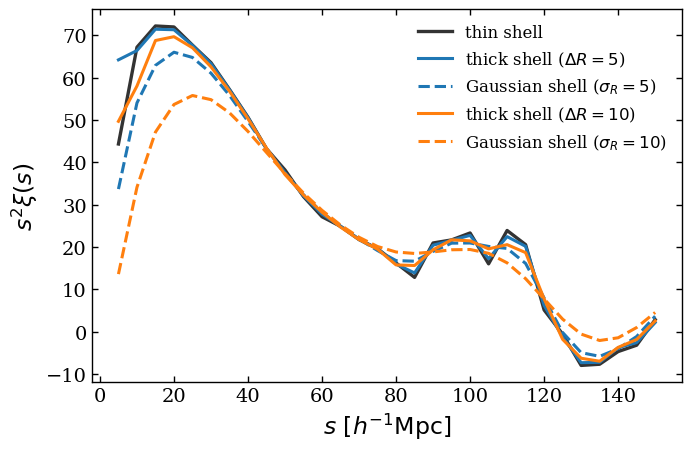

In [13]:

with plt.rc_context(STYLE):
    fig, ax = plt.subplots(figsize=(7.2, 4.8))
    styles = {
        "thin shell": dict(color="0.20", ls="-", lw=2.4),
        r"thick shell ($\Delta R=5$)": dict(color=COLORS["blue"], ls="-", lw=2.2),
        r"Gaussian shell ($\sigma_R=5$)": dict(color=COLORS["blue"], ls="--", lw=2.2),
        r"thick shell ($\Delta R=10$)": dict(color=COLORS["orange"], ls="-", lw=2.2),
        r"Gaussian shell ($\sigma_R=10$)": dict(color=COLORS["orange"], ls="--", lw=2.2),
    }
    for label, data in iso_curves.items():
        ax.plot(data.s, data.s ** 2 * data.xi, label=label, **styles[label])

    ax.set_xlabel(r"$s\ [h^{-1}\mathrm{Mpc}]$")
    ax.set_ylabel(r"$s^2\xi(s)$")
    ax.grid(False)
    ax.legend(frameon=False, ncol=1)
    ax.tick_params(direction="in", top=True, right=True, width=1.0, length=4)
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

    fig.tight_layout()
    fig.savefig(FIGS_DIR / "corr2pcf_binning_window_shell_gaussian_shell_comparison.png", dpi=240, bbox_inches="tight")
    plt.show()


## 4. Low-level anisotropic window composition

For the redshift-space 2PCF, the usual ring window can be factored into a transverse part and a line-of-sight part. The Gaussian-ring variant uses the same line-of-sight factor but multiplies the transverse ring by a Gaussian factor. The first cell demonstrates this lower-dimensional composition explicitly. The following cell then packages the same Gaussian ring into one custom Fourier-space kernel and supplies a callable mapping from each $(s,\mu)$ sample to its transverse radius $R$ and line-of-sight displacement $H$. This lets the ordinary `Corr_2PCF` task use the custom geometry without defining a task subclass.

In [14]:
@njit
def kernel_ring_2d(ki, kj, kk, R):
    k_perp = np.sqrt(ki * ki + kj * kj)
    return jn_numba(0, 2.0 * np.pi * k_perp * R)


@njit
def kernel_gauss_2d(ki, kj, kk, sigma_perp):
    k_perp = np.sqrt(ki * ki + kj * kj)
    q = 2.0 * np.pi * k_perp * sigma_perp
    return np.exp(-0.5 * q * q)


@njit
def kernel_double_delta_1d(ki, kj, kk, H):
    return np.cos(2.0 * np.pi * kk * H)


reference_field = SFCField(data_path=str(SFC_PATH), threads=THREADS)
R_demo = 30.0
H_demo = 20.0
sigma_demo = 5.0

W_ring_2d = WindowFunc(
    {"type": "ring_2d", "func": kernel_ring_2d, "len_args": {"R": R_demo}, "kernel_mode": "octant"},
    reference_field.sfc_info,
    threads=THREADS,
)
W_gauss_2d = WindowFunc(
    {"type": "gauss_2d", "func": kernel_gauss_2d, "len_args": {"sigma_perp": sigma_demo}, "kernel_mode": "octant"},
    reference_field.sfc_info,
    threads=THREADS,
)
W_los_1d = WindowFunc(
    {"type": "double_delta_1d", "func": kernel_double_delta_1d, "len_args": {"H": H_demo}, "kernel_mode": "octant"},
    reference_field.sfc_info,
    threads=THREADS,
)

W_ring_3d = W_ring_2d * W_los_1d
W_gauss_ring_3d = W_ring_2d * W_gauss_2d * W_los_1d
print("Constructed W_ring_3d and W_gauss_ring_3d from lower-dimensional factors.")

23:44:13 - INFO - pyhermes.io.base:SFCField - Reading SFCField data from ---> /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples/output/quijote8000_snap004_sfc.pkl <---
23:44:13 - INFO - pyhermes.io.base:SFCField - epsilon: Shape(256, 256, 256), Min = -3.215e-06, Max = 1.343e-05, Mean = 5.96e-08, Sum = 1
Constructed W_ring_3d and W_gauss_ring_3d from lower-dimensional factors.


In [15]:
@njit
def window_function_gaussian_ring_numba(ki, kj, kk, R, H, sigma_perp):
    k_perp = np.sqrt(ki * ki + kj * kj)
    q_ring = 2.0 * np.pi * k_perp * R
    q_smooth = 2.0 * np.pi * k_perp * sigma_perp
    q_parallel = 2.0 * np.pi * kk * H
    return (
        jn_numba(0, q_ring)
        * np.exp(-0.5 * q_smooth * q_smooth)
        * np.cos(q_parallel)
    )


def mapping_smu_to_gaussian_ring(sample, binning_window):
    params = copy.deepcopy(binning_window)
    s = float(sample["s"])
    mu = float(sample["mu"])
    params["len_args"]["R"] = s * np.sqrt(max(0.0, 1.0 - mu * mu))
    params["len_args"]["H"] = s * mu
    return params


gaussian_ring_win_params = {
    "type": "gaussian_ring",
    "func": window_function_gaussian_ring_numba,
    "len_args": {"R": None, "H": None, "sigma_perp": 5.0},
    "mapping": mapping_smu_to_gaussian_ring,
    "kernel_mode": "octant",
}

### 4.1 Lightweight custom-window tasks

The same `param_2pcf_smu_test.yaml` configuration now provides a small common sampling grid for both the built-in ring and the custom Gaussian-ring dictionary. The custom dictionary is assigned directly to `task.binning_window`, so the standard task handles its callable kernel and $(s,\mu)$ mapping exactly like a built-in geometry. Running both estimators on this grid is a quick functional check before loading the denser production results.

In [16]:
ring_test_task = Corr_2PCF(param_task=copy.deepcopy(smu_test_params))
ring_test_task.threads = THREADS
corr_ring_test = ring_test_task.run(save_result=False)

gauss_ring_test_task = Corr_2PCF(param_task=copy.deepcopy(smu_test_params))
gauss_ring_test_task.binning_window = copy.deepcopy(gaussian_ring_win_params)
gauss_ring_test_task.threads = THREADS
corr_gauss_ring_test = gauss_ring_test_task.run(save_result=False)


23:44:15 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
23:44:15 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.sfc_field' from 'empty' to './output/quijote8000_snap004_sfc.pkl'
23:44:15 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.random' from 'None' to 'uniform'
23:44:15 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.binning_window'.
23:44:15 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.sampling'.
23:44:15 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.threads' from '1' to '4'
23:44:15 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.fout_path' from 'empty' to './output/quijote8000_snap004_2pcf_smu_test.pkl'
23:44:15 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Corr_2PCF runtime configuration: running on 1 MPI ranks with 8 threads per rank
23:44:15 - INFO - pyhe

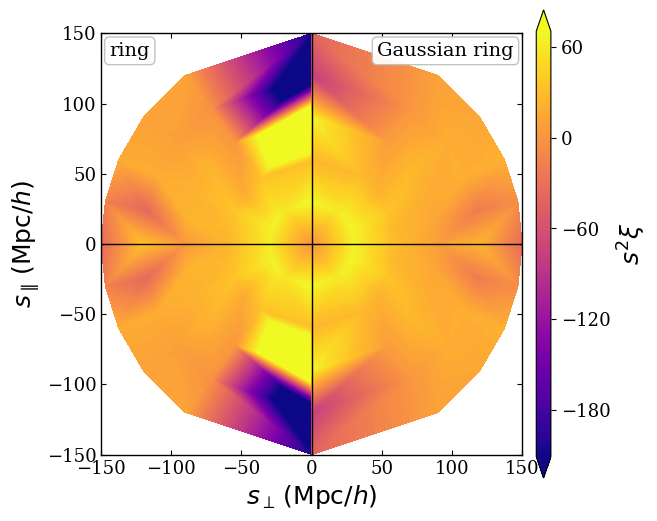

In [17]:
plot_corr2pcf_2d(
    corr_ring_test,
    corr_gauss_ring_test,
    label1="ring",
    label2="Gaussian ring",
    s_min=0.0,
)
plt.tight_layout()
plt.show()


## 5. Saved production-resolution RSD results

The interactive checks above use the $6\times6$ grid from `param_2pcf_smu_test.yaml`. The final figure instead reads the denser, previously saved redshift-space results used in the paper. Keeping production execution outside this notebook makes `Run All` practical while preserving the full-resolution scientific comparison.

In [18]:
ring_output = OUTPUT_DIR / "quijote8000_snap004_rsd_2pcf_smu.pkl"
gauss_ring_output = OUTPUT_DIR / "quijote8000_snap004_rsd_2pcf_smu_gaussian_ring_sigma5.pkl"

missing = [path for path in (ring_output, gauss_ring_output) if not path.exists()]
if missing:
    raise FileNotFoundError("Missing production output(s): " + ", ".join(map(str, missing)))

print(f"ring result         : {ring_output}")
print(f"Gaussian-ring result: {gauss_ring_output}")


ring result         : /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples/output/quijote8000_snap004_rsd_2pcf_smu.pkl
Gaussian-ring result: /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples/output/quijote8000_snap004_rsd_2pcf_smu_gaussian_ring_sigma5.pkl


### 5.1 Ring versus Gaussian ring

The plotted quantity is \(\log(1+\xi)\). The two panels use the same color scale and contour levels so that the response to the transverse Gaussian factor can be read directly.

23:44:37 - INFO - pyhermes.io.base:Corr2PCFData - Reading 2PCF data from ---> /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples/output/quijote8000_snap004_rsd_2pcf_smu.pkl <---
23:44:37 - INFO - pyhermes.io.base:Corr2PCFData - s: Num = 46, Min = 0, Max = 180
23:44:37 - INFO - pyhermes.io.base:Corr2PCFData - mu: Num = 51, Min = 0, Max = 1
23:44:37 - INFO - pyhermes.io.base:Corr2PCFData - Products loaded: ['delta_dd', 'rr', 'xi']
23:44:37 - INFO - pyhermes.io.base:Corr2PCFData - Reading 2PCF data from ---> /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples/output/quijote8000_snap004_rsd_2pcf_smu_gaussian_ring_sigma5.pkl <---
23:44:37 - INFO - pyhermes.io.base:Corr2PCFData - s: Num = 46, Min = 0, Max = 180
23:44:37 - INFO - pyhermes.io.base:Corr2PCFData - mu: Num = 51, Min = 0, Max = 1
23:44:37 - INFO - pyhermes.io.base:Corr2PCFData - Products loaded: ['delta_dd', 'rr', 'xi']


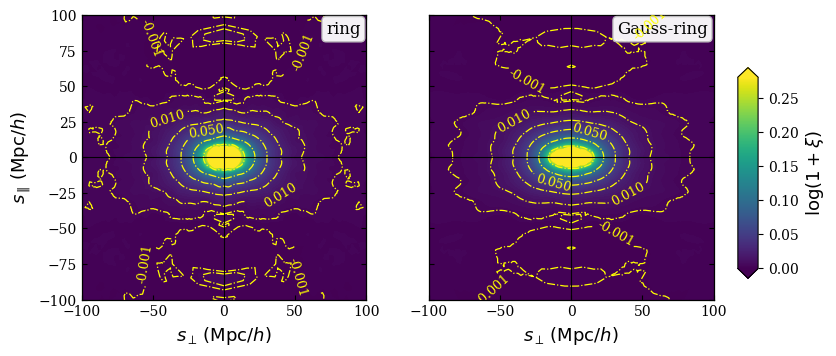

In [19]:
corr_ring = Corr2PCFData(data_path=str(ring_output), threads=THREADS)
corr_gauss_ring = Corr2PCFData(data_path=str(gauss_ring_output), threads=THREADS)

plot_kwargs = dict(
    s_min=0.0,
    add_contour=True,
    value="log10_1p_xi",
    cmap="viridis",
    vmin=-0.0005,
    vmax=0.28,
    n_levels=121,
    contour_levels=[-0.001, 0.003, 0.010, 0.025, 0.050, 0.100, 0.200],
    contour_kwargs={"colors": "yellow", "linewidths": 0.9, "linestyles": "dashdot"},
    center_line_kwargs={"color": "black", "lw": 0.8, "alpha": 0.95, "zorder": 20},
    label_fontsize=13,
    tick_fontsize=10,
    text_fontsize=12,
    spine_linewidth=0.9,
)

fig, axes = plt.subplots(1, 2, figsize=(8.1, 3.9), sharex=True, sharey=True)
fig.subplots_adjust(left=0.08, right=0.86, bottom=0.15, top=0.93, wspace=0.22)

for ax, corr, label in zip(axes, [corr_ring, corr_gauss_ring], ["ring", "Gauss-ring"]):
    plot_corr2pcf_2d(corr, ax=ax, label1=label, add_colorbar=False, **plot_kwargs)
    ax.set_xlim(-100, 100)
    ax.set_ylim(-100, 100)
    ax.set_aspect("equal")

axes[1].set_ylabel("")
axes[1].tick_params(labelleft=False)

norm = mcolors.Normalize(vmin=plot_kwargs["vmin"], vmax=plot_kwargs["vmax"])
sm = cm.ScalarMappable(norm=norm, cmap=plot_kwargs["cmap"])
sm.set_array([])
cax = fig.add_axes([0.89, 0.23, 0.025, 0.54])
cbar = fig.colorbar(sm, cax=cax, orientation="vertical", extend="both")
cbar.set_label(r"$\log(1+\xi)$", fontsize=13)
cbar.ax.tick_params(labelsize=10)

fig.savefig(FIGS_DIR / "corr2pcf_ring_gaussian_ring_smu.png", dpi=240, bbox_inches="tight")
plt.show()

## 6. Summary

- YAML files and `Corr_2PCF` provide the ordinary high-level workflow.
- `Corr2PCFData` separates task execution from plotting and downstream analysis.
- The direct field--window--field calculation exposes how one value of $\xi(s)$ is formed.
- `WindowFunc` and a small task subclass expose the low-level extension point for a new binning geometry.
- Isotropic and test-grid anisotropic calculations run in the notebook; the last figure reads saved production-resolution RSD results.

## Next steps

This notebook completes the two-point branch, from the Quick Start estimator to anisotropic production outputs and custom binning windows. Continue with `corr3pcf.ipynb` to move from pairs to angular and multipole triangle statistics.